# 🔌 Household Energy Tracker

## Import Modules 📔📚

In [1]:
!python -m pip install -r requirements.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable


## 📁 Create Dataset

In [2]:
!python data_generate.py

## 📌 Tasks Checklist

### 🔹 Data Preparation

In [3]:
df = pd.read_csv("household_energy_usage.csv")

df.head(5)

df["Reading_Date"] = pd.to_datetime(df["Reading_Date"])
df["Reading_Month"] = df["Reading_Date"].dt.month_name()
df["Reading_Day_Of_Week"] = df["Reading_Date"].dt.day_name()

df["Average_Consumption_Per_Day"] = df["Total_Energy_Units"] / 24


### 🔹Data Cleaning

In [4]:
df.isna().sum()

Reading_ID                      0
Household_ID                    0
Region                          0
Reading_Date                    0
Electricity_kWh                10
Gas_Consumption_m3              6
Water_Liters                    1
Temperature_C                   4
Total_Energy_Units              4
Reading_Month                   0
Reading_Day_Of_Week             0
Average_Consumption_Per_Day     4
dtype: int64

In [5]:
df = df.dropna()
df.isna().sum()

Reading_ID                     0
Household_ID                   0
Region                         0
Reading_Date                   0
Electricity_kWh                0
Gas_Consumption_m3             0
Water_Liters                   0
Temperature_C                  0
Total_Energy_Units             0
Reading_Month                  0
Reading_Day_Of_Week            0
Average_Consumption_Per_Day    0
dtype: int64

In [6]:
if df.duplicated().sum() > 0:
    print(f"{df.duplicated().sum()} Duplicate rows found and will be removed.")
    df = df.drop_duplicates()
    print(f"Now there are {df.duplicated().sum()} duplicate rows after removing duplicates.")
else:
    print("No duplicate rows found.")

15 Duplicate rows found and will be removed.
Now there are 0 duplicate rows after removing duplicates.


### 🔹 Data Analysis

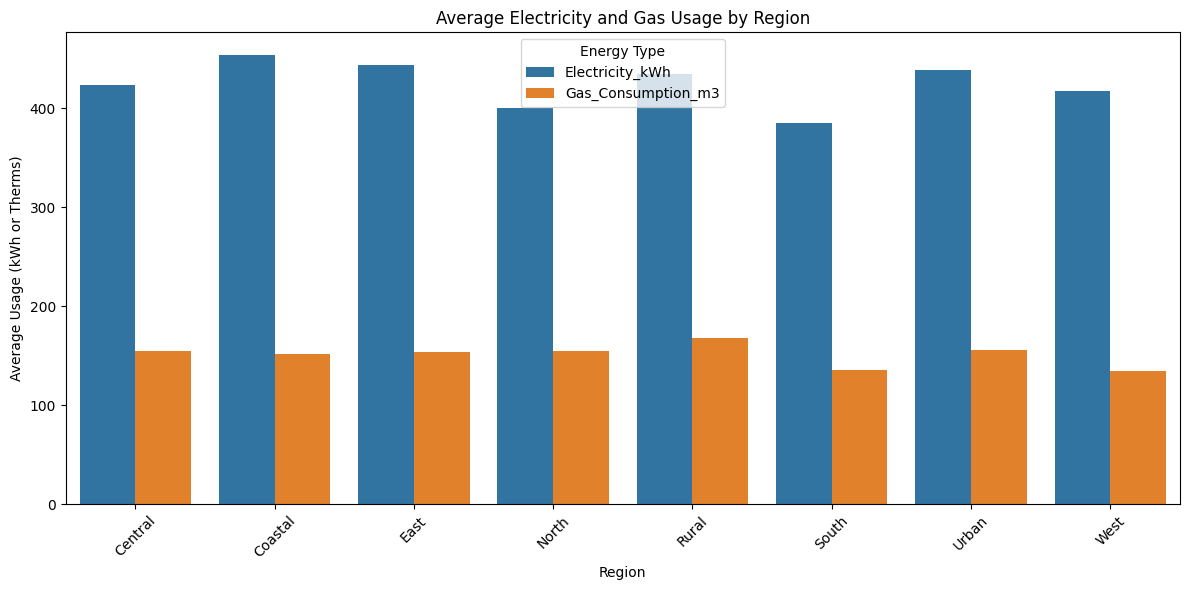

In [7]:
average_usage = df.groupby("Region")[["Electricity_kWh", "Gas_Consumption_m3"]].mean()

plt.figure(figsize=(12, 6))
sns.barplot(data=average_usage.reset_index().melt(id_vars="Region"), x="Region", y="value", hue="variable")
plt.title("Average Electricity and Gas Usage by Region")
plt.ylabel("Average Usage (kWh or Therms)")
plt.xlabel("Region")
plt.xticks(rotation=45)
plt.legend(title="Energy Type", loc="best")
plt.tight_layout()
plt.show()

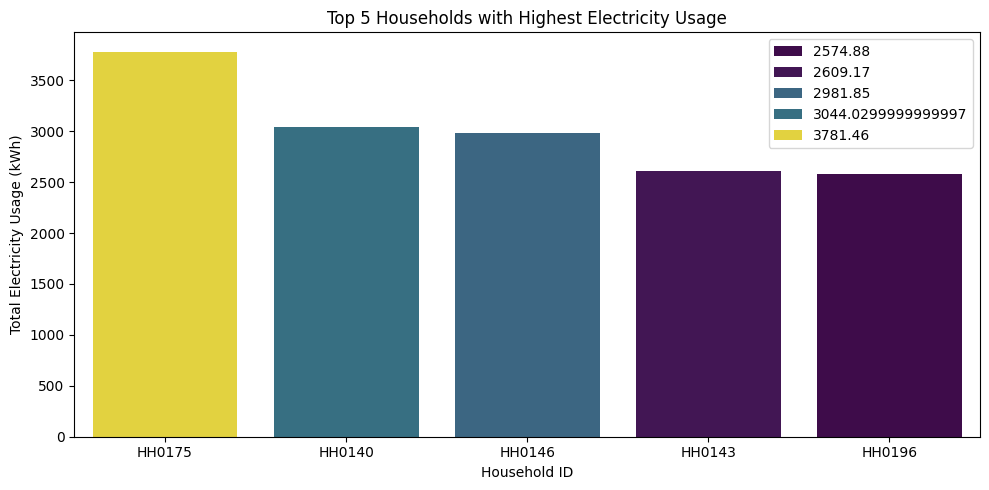

In [8]:
top_households = df.groupby("Household_ID")["Electricity_kWh"].sum().nlargest(5)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_households.index, y=top_households.values, palette="viridis", hue=top_households.values)
plt.title("Top 5 Households with Highest Electricity Usage")
plt.ylabel("Total Electricity Usage (kWh)")
plt.xlabel("Household ID")
plt.tight_layout()
plt.show()

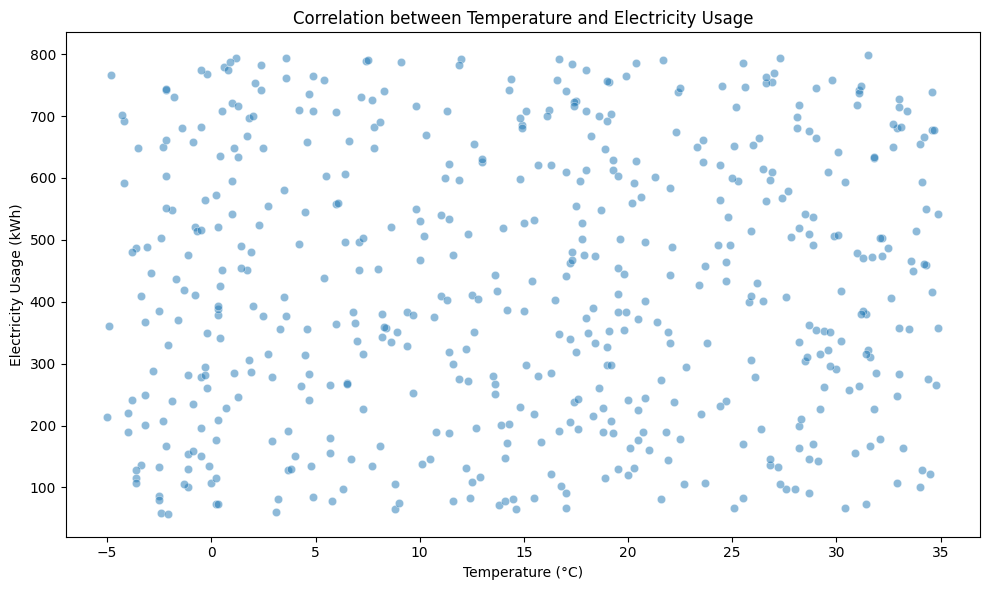

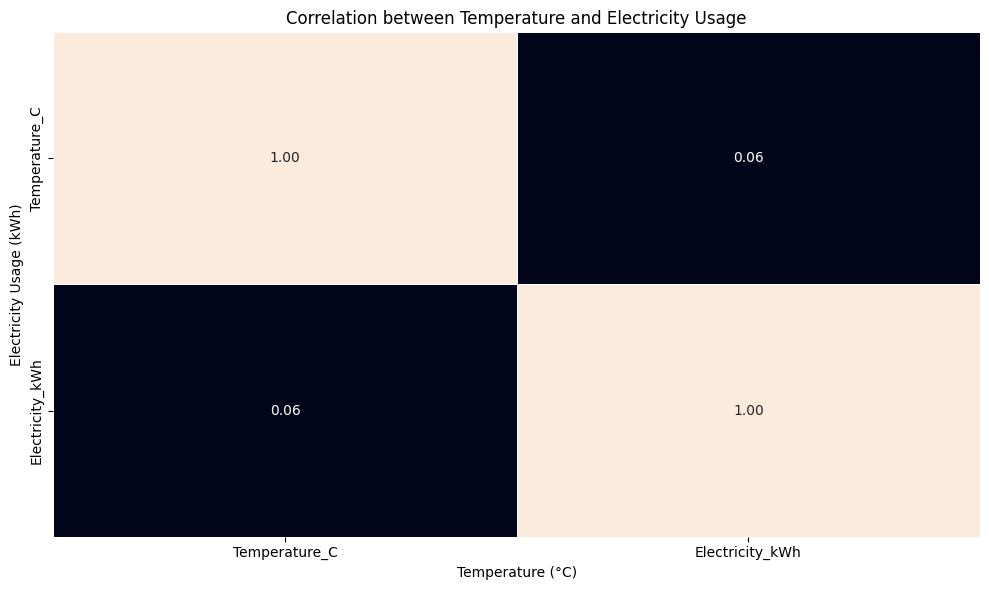

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Temperature_C", y="Electricity_kWh", alpha=0.5)
plt.title("Correlation between Temperature and Electricity Usage")
plt.xlabel("Temperature (°C)")
plt.ylabel("Electricity Usage (kWh)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df[["Temperature_C", "Electricity_kWh"]].corr(), annot=True, cmap="rocket", cbar=False, fmt=".2f", linewidths=0.5)
plt.title("Correlation between Temperature and Electricity Usage")
plt.xlabel("Temperature (°C)")
plt.ylabel("Electricity Usage (kWh)")
plt.tight_layout()
plt.show()

In [10]:
peak_days = df[df["Electricity_kWh"] == df["Electricity_kWh"].max()]
print("Days with Peak Total Energy Consumption:")
print(peak_days[["Household_ID", "Reading_Date", "Electricity_kWh", "Gas_Consumption_m3"]])

Days with Peak Total Energy Consumption:
    Household_ID Reading_Date  Electricity_kWh  Gas_Consumption_m3
243       HH0215   2024-07-21           798.12              280.41


### 🔹 Data Visualization

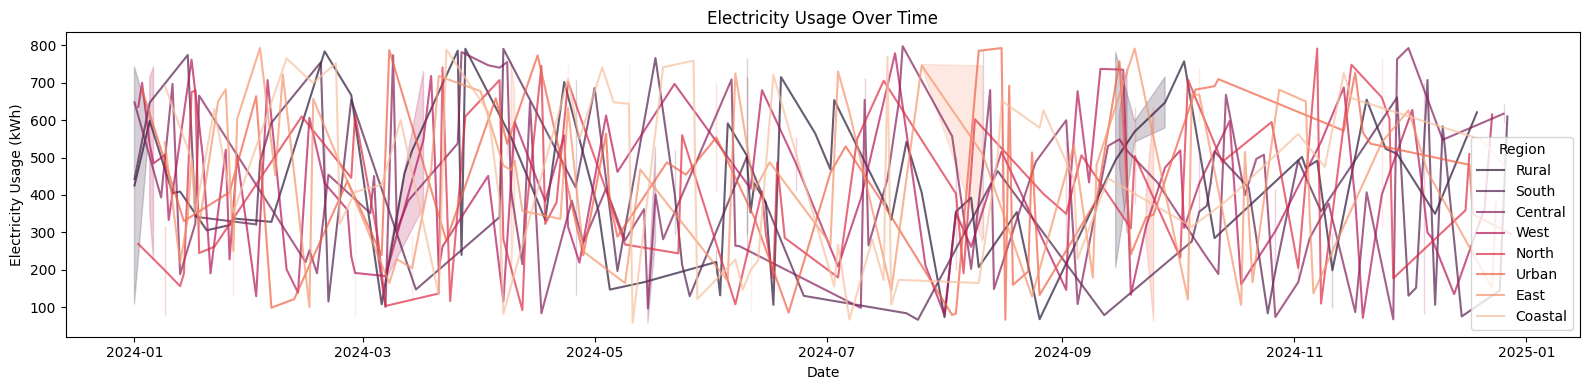

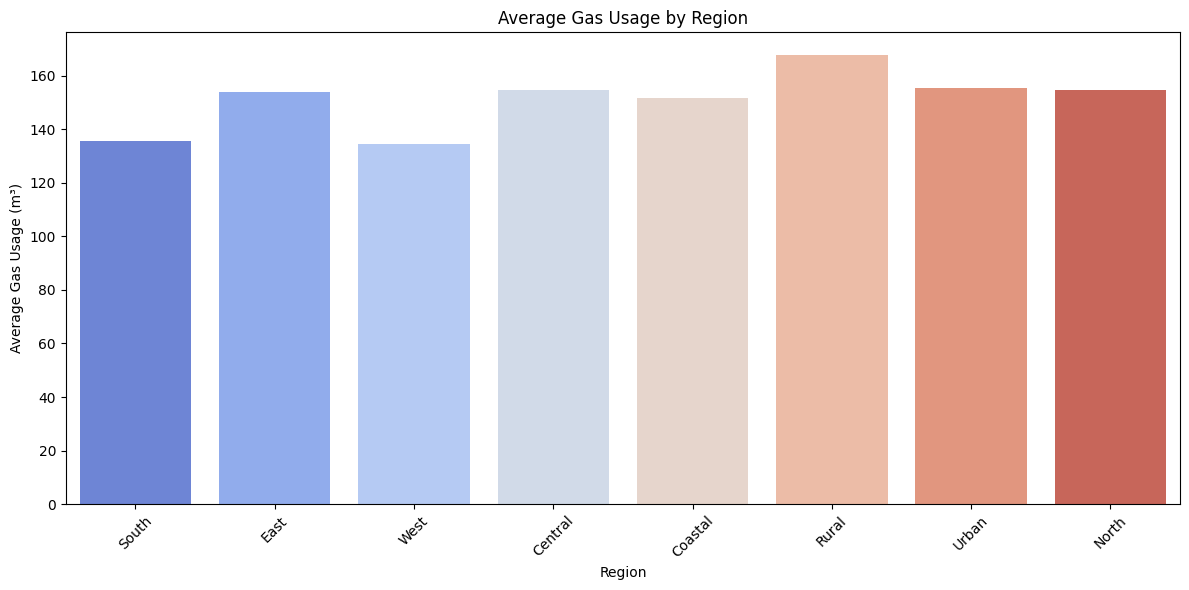

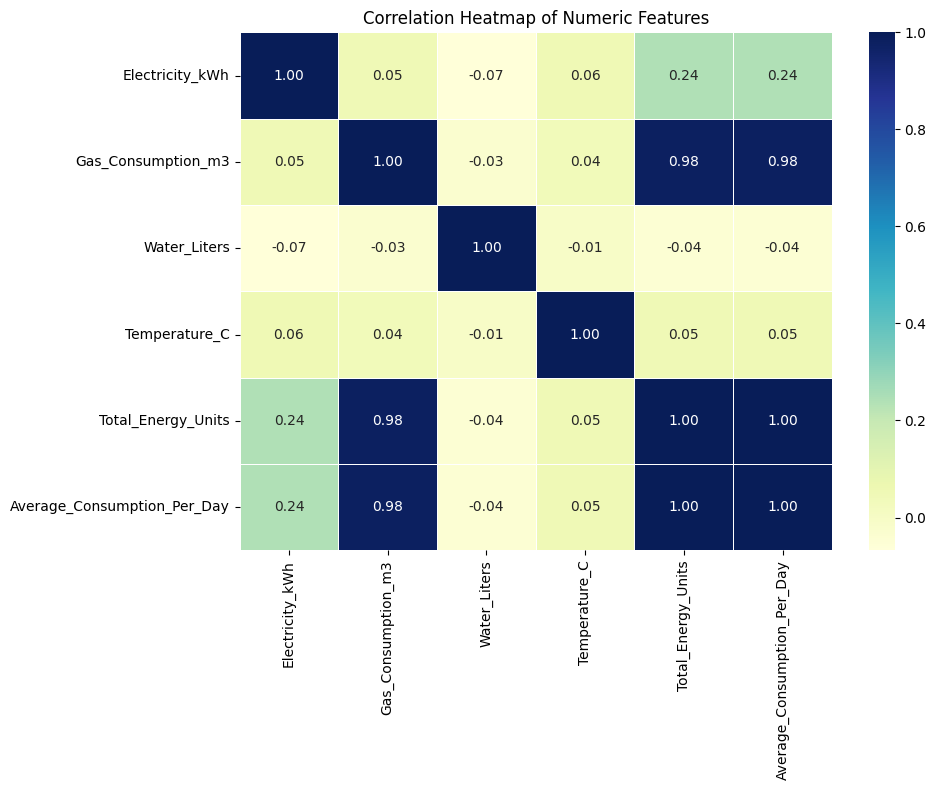

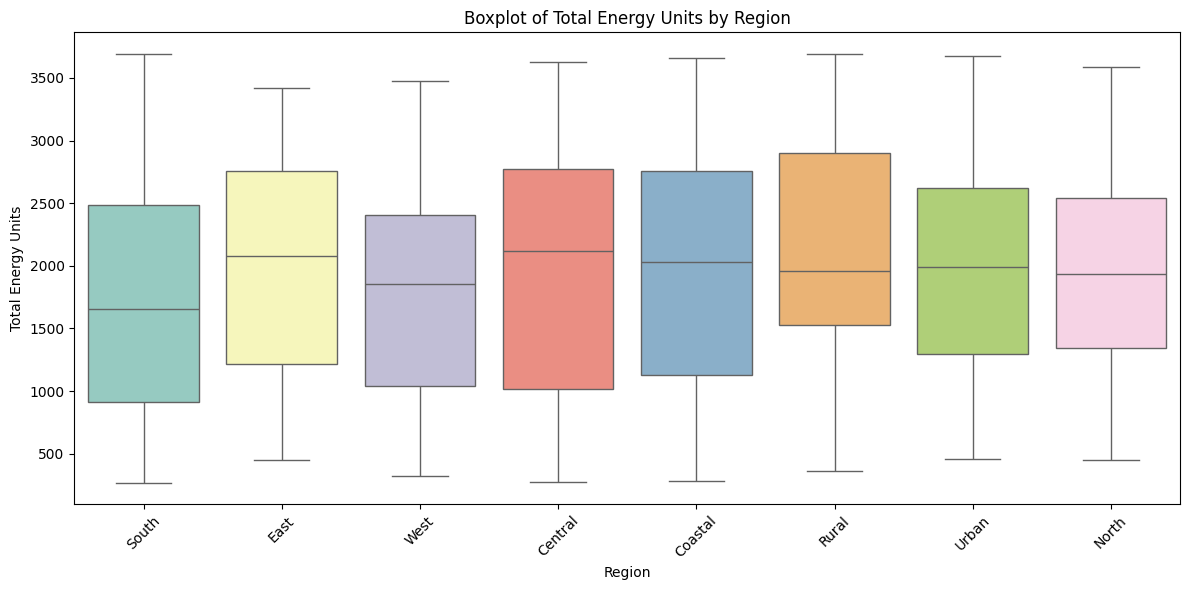

In [11]:
plt.figure(figsize=(16, 4))
df_sorted = df.sort_values("Reading_Date")
sns.lineplot(data=df_sorted, x="Reading_Date", y="Electricity_kWh", hue="Region", alpha=0.7, palette="rocket")
plt.title("Electricity Usage Over Time")
plt.xlabel("Date")
plt.ylabel("Electricity Usage (kWh)")
plt.legend(title="Region", loc="best")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Region", y="Gas_Consumption_m3", errorbar=None, palette="coolwarm", hue="Region")
plt.title("Average Gas Usage by Region")
plt.xlabel("Region")
plt.ylabel("Average Gas Usage (m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="YlGnBu", cbar=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Region", y="Total_Energy_Units", palette="Set3", hue="Region")
plt.title("Boxplot of Total Energy Units by Region")
plt.xlabel("Region")
plt.ylabel("Total Energy Units")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()